Init and define utility func()

In [112]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

N = 10
MAX_SCOPE = 1000
INIT_SPEED = 100
R_REPULSE = 10
DELTA_T = 0.1
MCS = 1000

class Vector:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def distance(self, another_one):
        return math.sqrt( (self.x - another_one.x) ** 2 +  (self.y - another_one.y) **2)

    def move(self, speed, delta_t: float) -> None: # speed is also a vector
        self.x = (self.x + speed.x * delta_t) % MAX_SCOPE  # periodic boundary
        self.y = (self.y + speed.y * delta_t) % MAX_SCOPE  # periodic boundary

class Animal:
    def __init__(self, name, _id, **kwargs):
        self.name = name  # wolf or sheep
        self.id = _id
        self.alive = True
        self.pos =  kwargs["pos"] # this is a vector
        self.speed = kwargs["speed"] # this is a vector

    def distance(self, other_animal  ):
        return self.pos.distance( other_animal.pos )

    def update_speed(self):
        pass

    def move(self, delta_t : float ):
        self.update_speed()
        self.pos.move(self.speed, delta_t)

def alive_animals( animals :[] ) -> []:
    return [ a for a in animals if a.alive ]

def draw():
    plt.figure(1)  # 选择图表1
    x = [w.pos.x for w in Wolves]
    y = [w.pos.y for w in Wolves]
    plt.scatter(x, y, marker='D')

    x = [s.pos.x for s in alive_animals(Sheep) ]
    y = [s.pos.y for s in alive_animals(Sheep) ]
    plt.scatter(x, y, marker='+')

In [116]:
def unit_test():
    assert (Vector(0,3).distance( Vector(4,0)) ==5)

    w1 = Animal("wolf", 1, pos= Vector(10,10), speed = Vector(3,1))
    assert( w1.pos.x == 10 and w1.pos.y == 10)
    w1.move(1)
    assert( w1.pos.x == 13 and w1.pos.y == 11)

    print("all passed")

unit_test()

all passed


In [39]:
def init() :
    positions_wolf = [Vector(p[0], p[1]) for p in zip(np.random.randint(0, MAX_SCOPE / 3, N),
                                                      np.random.randint(0, MAX_SCOPE / 3, N))]
    positions_sheep = [Vector(p[0], p[1]) for p in zip(np.random.randint(MAX_SCOPE / 2, MAX_SCOPE, N),
                                                       np.random.randint(MAX_SCOPE / 2, MAX_SCOPE, N))]
    speed_wolf = [Vector(p[0], p[1]) for p in zip(np.random.randint(INIT_SPEED/2, INIT_SPEED, N),
                          np.random.randint(INIT_SPEED/2, INIT_SPEED, N) )]
    speed_sheep = [Vector(p[0], p[1]) for p in zip(np.random.randint(0, INIT_SPEED, N),
                          np.random.randint(0, INIT_SPEED, N) )]
    for i in range(N):
        Wolves.append(Animal("wolf", i, pos = positions_wolf[i], speed = speed_wolf[i]   ))
        Sheep.append(Animal("sheep", i, pos = positions_sheep[i], speed = speed_sheep[i] ))


 alive sheep is 10
[(88, 266), (175, 27), (280, 308), (146, 286), (41, 251), (11, 44), (211, 108), (301, 41), (19, 113), (222, 166)]


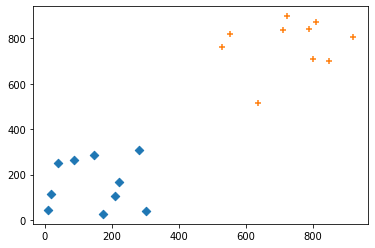

In [127]:
Wolves = []
Sheep = []
init()
print(f" alive sheep is { len( alive_animals(Sheep) ) }")
print( [(w.pos.x, w.pos.y) for w in Wolves])
draw()

[(24, 153), (115, 53), (277, 136), (194, 118), (248, 52), (142, 95), (216, 230), (99, 136), (104, 217), (322, 173)]


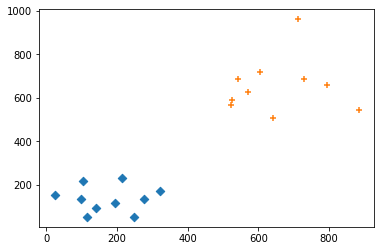

In [126]:
for i in range(100):
    for w in Wolves:
        w.move(DELTA_T)
    for s in alive_animals(Sheep):
        s.move(DELTA_T)
print( [(w.pos.x, w.pos.y) for w in Wolves])
draw()


